# Stage 5 — Leakage-Safe Feature Pool Construction

## 5.1 Configuration for feature construction and selection

This stage builds the candidate feature pool before supervised feature selection. Each indicator can contribute a 2022 level value, a 2018–2022 mean, and a 2018–2022 change. The mean is an aggregation feature built with `groupby` and `mean`, which keeps the design cross-sectional while using more than one year of information.

In [338]:
MAX_INDICATOR_MISSINGNESS = 0.50
MAX_FINAL_FEATURE_MISSINGNESS = 0.50
CANDIDATE_LIMIT = 60
FINAL_INDICATOR_LIMIT = 25
FINAL_ENGINEERED_FEATURE_LIMIT = 25
REDUNDANCY_LIMIT = 0.90
ENGINEERED_REDUNDANCY_LIMIT = 0.90

LEVEL_VALUE_COLUMN = f"value_{PREDICTOR_LEVEL_YEAR}"
MEAN_VALUE_COLUMN = f"mean_{MEAN_START_YEAR}_{MEAN_END_YEAR}"
CHANGE_VALUE_COLUMN = f"change_{CHANGE_START_YEAR}_{CHANGE_END_YEAR}"

print("Target year:", TARGET_YEAR)
print("Predictor level year:", PREDICTOR_LEVEL_YEAR)
print("Mean feature:", MEAN_START_YEAR, "to", MEAN_END_YEAR)
print("Change feature:", CHANGE_START_YEAR, "to", CHANGE_END_YEAR)
print("Maximum allowed indicator missingness:", MAX_INDICATOR_MISSINGNESS)
print("Maximum allowed final engineered-feature missingness:", MAX_FINAL_FEATURE_MISSINGNESS)
print("Candidate indicator shortlist size:", CANDIDATE_LIMIT)
print("Maximum final original WDI indicators:", FINAL_INDICATOR_LIMIT)
print("Maximum final engineered predictor columns:", FINAL_ENGINEERED_FEATURE_LIMIT)
print("Maximum allowed redundancy among engineered predictors:", ENGINEERED_REDUNDANCY_LIMIT)

all_2022_values = fixed_year_values(country_wdi, PREDICTOR_LEVEL_YEAR, value_name=LEVEL_VALUE_COLUMN)
all_2022_values = all_2022_values[all_2022_values["country_code"].isin(target_df["country_code"])].copy()

target_country_count = target_df["country_code"].nunique()
indicator_missingness_2022 = (
    all_2022_values
    .groupby(["indicator_code", "indicator_name"], as_index=False)
    .agg(observed_countries=(LEVEL_VALUE_COLUMN, "count"))
)
indicator_missingness_2022["missing_countries"] = target_country_count - indicator_missingness_2022["observed_countries"]
indicator_missingness_2022["missing_pct"] = indicator_missingness_2022["missing_countries"] / target_country_count
indicator_missingness_2022["source_year"] = PREDICTOR_LEVEL_YEAR
indicator_missingness_2022 = indicator_missingness_2022.sort_values("missing_pct")

indicator_missingness_2022.to_csv(TABLE_DIR / "indicator_missingness_2022.csv", index=False)
display(indicator_missingness_2022.head(10))

Target year: 2023
Predictor level year: 2022
Mean feature: 2018 to 2022
Change feature: 2018 to 2022
Maximum allowed indicator missingness: 0.5
Maximum allowed final engineered-feature missingness: 0.5
Candidate indicator shortlist size: 60
Maximum final original WDI indicators: 25
Maximum final engineered predictor columns: 25
Maximum allowed redundancy among engineered predictors: 0.9


,indicator_code,indicator_name,observed_countries,missing_countries,missing_pct,source_year
815,WB_WDI_SH_DYN_MORT,"Mortality rate, under-5 (per 1,000 live births)",146,0,0.000000,2022
1121,WB_WDI_SP_POP_65UP_MA_IN,"Population ages 65 and above, male",120,26,0.178082,2022
586,WB_WDI_NY_GDP_MKTP_CN,GDP (current LCU),119,27,0.184932,2022
1065,WB_WDI_SP_DYN_IMRT_FE_IN,"Mortality rate, infant, female (per 1,000 live...",118,28,0.191781,2022
816,WB_WDI_SH_DYN_MORT_FE,"Mortality rate, under-5, female (per 1,000 liv...",118,28,0.191781,2022
70,WB_WDI_CC_PER_RNK,Control of Corruption: Percentile Rank,118,28,0.191781,2022
811,WB_WDI_SH_DYN_1519,Probability of dying among adolescents ages 15...,117,29,0.198630,2022
1180,WB_WDI_TM_VAL_MRCH_HI_ZS,Merchandise imports from high-income economies...,117,29,0.198630,2022
18,WB_WDI_AG_SRF_TOTL_K2,Surface area (sq. km),117,29,0.198630,2022
840,WB_WDI_SH_IMM_MEAS,"Immunization, measles (% of children ages 12-2...",117,29,0.198630,2022


## 5.2 Remove target-like and leakage-risk indicators

In [340]:
def is_target_like_indicator(indicator_name, indicator_code):
    text = f"{indicator_name} {indicator_code}".lower()
    leakage_terms = [
        "mortality", "death", "deaths", "dying", "survival", "life expectancy", "lifespan",
        "infant mortality", "neonatal", "under-5", "under five", "under-five",
        "stillbirth", "hci", "human capital index"
    ]
    return any(term in text for term in leakage_terms)

eligible_indicator_base = indicator_missingness_2022.copy()
eligible_indicator_base["target_like"] = eligible_indicator_base.apply(
    lambda row: is_target_like_indicator(row["indicator_name"], row["indicator_code"]),
    axis=1
)

eligible_indicator_base["passes_missingness"] = eligible_indicator_base["missing_pct"] <= MAX_INDICATOR_MISSINGNESS

eligible_indicators = eligible_indicator_base[
    eligible_indicator_base["passes_missingness"] & (~eligible_indicator_base["target_like"])
].copy()

excluded_target_like = eligible_indicator_base[eligible_indicator_base["target_like"]].copy()
excluded_high_missing = eligible_indicator_base[~eligible_indicator_base["passes_missingness"]].copy()

eligible_indicators.to_csv(TABLE_DIR / "eligible_indicators_after_2022_missingness_and_leakage_filters.csv", index=False)
excluded_target_like.to_csv(TABLE_DIR / "excluded_target_like_indicators.csv", index=False)
excluded_high_missing.to_csv(TABLE_DIR / "excluded_high_2022_missingness_indicators.csv", index=False)

print("Indicators with 2022 observations before filters:", len(indicator_missingness_2022))
print("Indicators after <=50% 2022 missingness and leakage filters:", len(eligible_indicators))
print("Target-like indicators excluded:", len(excluded_target_like))
print("High-2022-missingness indicators excluded:", len(excluded_high_missing))

Indicators with 2022 observations before filters: 1239
Indicators after <=50% 2022 missingness and leakage filters: 662
Target-like indicators excluded: 32
High-2022-missingness indicators excluded: 547


## 5.3 Build level, mean, and change feature pools

The feature pool contains three summaries for eligible indicators: exact 2022 values, the 2018–2022 mean, and the 2018–2022 change. The mean is a group-level aggregation over years for each country-indicator pair.

,feature_pool,rows,indicators,countries
0,2022 level,63962,662,146
1,2018-2022 mean,65265,662,146
2,2018-2022 change,63093,659,146


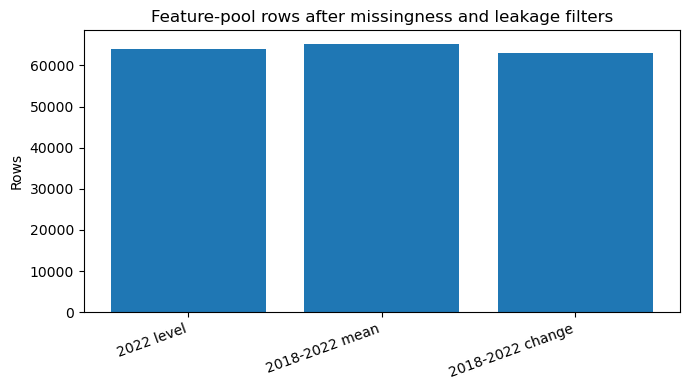

In [342]:
eligible_codes = set(eligible_indicators["indicator_code"])

level_2022_pool = all_2022_values[all_2022_values["indicator_code"].isin(eligible_codes)].copy()

mean_2018_2022_pool = mean_between_years(country_wdi, MEAN_START_YEAR, MEAN_END_YEAR)
mean_2018_2022_pool = mean_2018_2022_pool[
    mean_2018_2022_pool["country_code"].isin(target_df["country_code"])
    & mean_2018_2022_pool["indicator_code"].isin(eligible_codes)
].copy()

change_2018_2022_pool = exact_change_between_years(country_wdi, CHANGE_START_YEAR, CHANGE_END_YEAR)
change_2018_2022_pool = change_2018_2022_pool[
    change_2018_2022_pool["country_code"].isin(target_df["country_code"])
    & change_2018_2022_pool["indicator_code"].isin(eligible_codes)
].copy()

level_2022_pool.to_csv(DATA_DIR / "feature_pool_2022_level_long.csv", index=False)
mean_2018_2022_pool.to_csv(DATA_DIR / "feature_pool_mean_2018_2022_long.csv", index=False)
change_2018_2022_pool.to_csv(DATA_DIR / "feature_pool_change_2018_2022_long.csv", index=False)

feature_pool_summary = pd.DataFrame({
    "feature_pool": ["2022 level", "2018-2022 mean", "2018-2022 change"],
    "rows": [len(level_2022_pool), len(mean_2018_2022_pool), len(change_2018_2022_pool)],
    "indicators": [
        level_2022_pool["indicator_code"].nunique(),
        mean_2018_2022_pool["indicator_code"].nunique(),
        change_2018_2022_pool["indicator_code"].nunique()
    ],
    "countries": [
        level_2022_pool["country_code"].nunique(),
        mean_2018_2022_pool["country_code"].nunique(),
        change_2018_2022_pool["country_code"].nunique()
    ]
})

feature_pool_summary.to_csv(TABLE_DIR / "feature_pool_summary_level_mean_change.csv", index=False)

display(feature_pool_summary)

plt.figure(figsize=(7, 4))
plt.bar(feature_pool_summary["feature_pool"], feature_pool_summary["rows"])
plt.title("Feature-pool rows after missingness and leakage filters")
plt.ylabel("Rows")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(VIS_DIR / "feature_pool_level_mean_change_summary.png", dpi=300)
plt.show()